<a href="https://colab.research.google.com/github/springboardmentorLive/Reality_AI/blob/NITISHA_SHINY/Copy_of_tasks_f7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TASK 1

In [ ]:
import pandas as pd

# Create sample data
data = {
    "Name": ["Asha", "Ravi", "Kumar", "Asha", None],
    "Age": [23, 25, None, 23, 30],
    "City": ["Delhi", None, "Chennai", "Delhi", "Mumbai"]
}

df = pd.DataFrame(data)

# Save to CSV
df.to_csv("sample_data.csv", index=False)

df


,Name,Age,City
0,Asha,23.0,Delhi
1,Ravi,25.0,None
2,Kumar,NaN,Chennai
3,Asha,23.0,Delhi
4,None,30.0,Mumbai


In [ ]:
# Load CSV
df = pd.read_csv("sample_data.csv")

print("Original Data:")
df


Original Data:


,Name,Age,City
0,Asha,23.0,Delhi
1,Ravi,25.0,NaN
2,Kumar,NaN,Chennai
3,Asha,23.0,Delhi
4,NaN,30.0,Mumbai


In [ ]:
df_dropna = df.dropna()
df_dropna


,Name,Age,City
0,Asha,23.0,Delhi
3,Asha,23.0,Delhi


In [ ]:
df_filled = df.fillna({
    "Name": "Unknown",
    "Age": df["Age"].mean(),   # Fill with mean age
    "City": "Not Provided"
})
df_filled


,Name,Age,City
0,Asha,23.00,Delhi
1,Ravi,25.00,Not Provided
2,Kumar,25.25,Chennai
3,Asha,23.00,Delhi
4,Unknown,30.00,Mumbai


In [ ]:
df_no_duplicates = df_filled.drop_duplicates()
df_no_duplicates


,Name,Age,City
0,Asha,23.00,Delhi
1,Ravi,25.00,Not Provided
2,Kumar,25.25,Chennai
4,Unknown,30.00,Mumbai


In [ ]:
df_no_duplicates.to_csv("cleaned_data.csv", index=False)
df_no_duplicates


,Name,Age,City
0,Asha,23.00,Delhi
1,Ravi,25.00,Not Provided
2,Kumar,25.25,Chennai
4,Unknown,30.00,Mumbai


TASK 2

In [ ]:
# Download an online GIF/video
!wget -O seal.gif https://media.giphy.com/media/ICOgUNjpvO0PC/giphy.gif

import cv2
import os

video_path = "/content/seal.gif"
output_folder = "frames1"
os.makedirs(output_folder, exist_ok=True)

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    raise IOError("Could not open video")

frame_count = 0
max_frames = 10

while frame_count < max_frames:
    ret, frame = cap.read()
    if not ret:
        break

    frame_path = os.path.join(output_folder, f"frame_{frame_count:03d}.jpg")
    cv2.imwrite(frame_path, frame)
    print("Saved:", frame_path)

    frame_count += 1

cap.release()
cv2.destroyAllWindows()


--2025-12-13 17:25:34--  https://media.giphy.com/media/ICOgUNjpvO0PC/giphy.gif
Resolving media.giphy.com (media.giphy.com)... 146.75.33.155
Connecting to media.giphy.com (media.giphy.com)|146.75.33.155|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 239321 (234K) [image/gif]
Saving to: ‘seal.gif’

seal.gif            100%[===================>] 233.71K  --.-KB/s    in 0.03s   

2025-12-13 17:25:34 (6.91 MB/s) - ‘seal.gif’ saved [239321/239321]

Saved: frames1/frame_000.jpg
Saved: frames1/frame_001.jpg
Saved: frames1/frame_002.jpg
Saved: frames1/frame_003.jpg
Saved: frames1/frame_004.jpg
Saved: frames1/frame_005.jpg
Saved: frames1/frame_006.jpg
Saved: frames1/frame_007.jpg
Saved: frames1/frame_008.jpg
Saved: frames1/frame_009.jpg


TASK 3

--2025-12-13 17:29:50--  https://github.com/opencv/opencv/raw/master/samples/data/vtest.avi
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/opencv/opencv/master/samples/data/vtest.avi [following]
--2025-12-13 17:29:51--  https://raw.githubusercontent.com/opencv/opencv/master/samples/data/vtest.avi
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8131690 (7.8M) [video/msvideo]
Saving to: ‘traffic.mp4’

traffic.mp4         100%[===================>]   7.75M  --.-KB/s    in 0.08s   

2025-12-13 17:29:51 (92.7 MB/s) - ‘traffic.mp4’ saved [8131690/8131690]



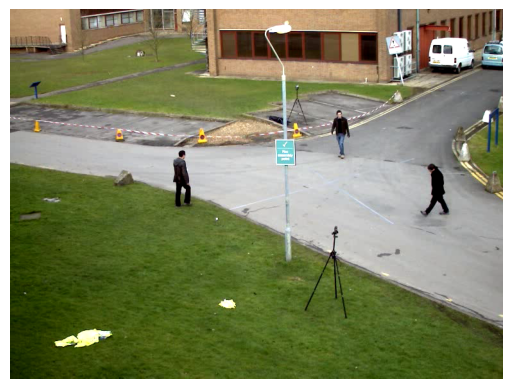

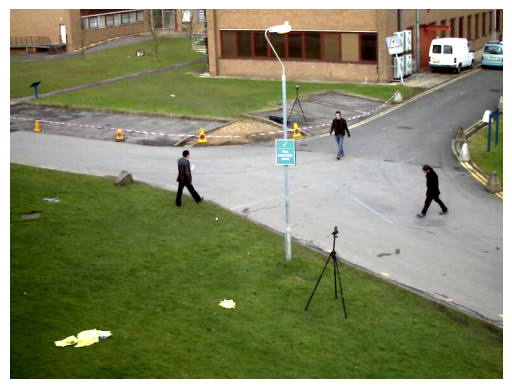

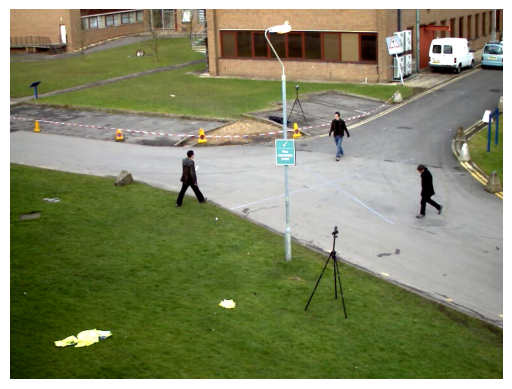

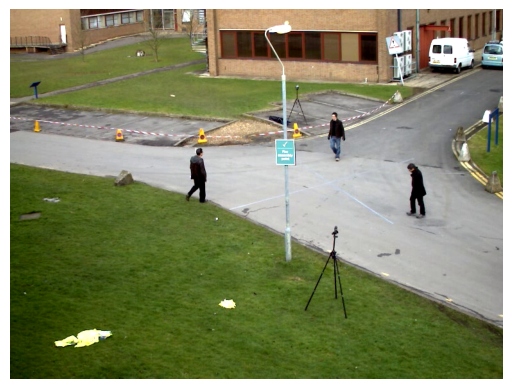

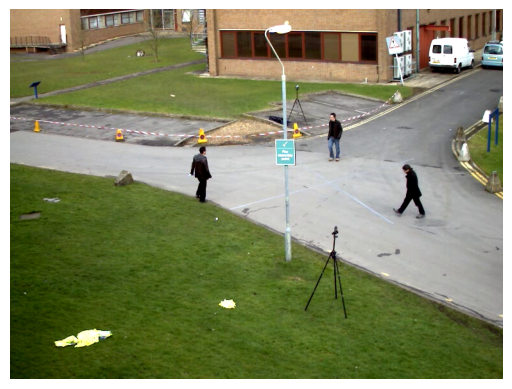

In [ ]:
!wget -O traffic.mp4 https://github.com/opencv/opencv/raw/master/samples/data/vtest.avi

import cv2
import matplotlib.pyplot as plt

cap = cv2.VideoCapture("/content/traffic.mp4")

if not cap.isOpened():
    raise IOError("Could not open video")

frame_count = 0
max_frames = 5

while frame_count < max_frames:
    ret, frame = cap.read()
    if not ret:
        break

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.imshow(frame_rgb)
    plt.axis("off")
    plt.show()

    frame_count += 1

cap.release()
cv2.destroyAllWindows()


TASK 4

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


In [ ]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df1 = pd.read_csv(url)
df1


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [ ]:
x = df1.iloc[:,:-1]
x

,total_bill,tip,sex,smoker,day,time
0,16.99,1.01,Female,No,Sun,Dinner
1,10.34,1.66,Male,No,Sun,Dinner
2,21.01,3.50,Male,No,Sun,Dinner
3,23.68,3.31,Male,No,Sun,Dinner
4,24.59,3.61,Female,No,Sun,Dinner
...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner
240,27.18,2.00,Female,Yes,Sat,Dinner
241,22.67,2.00,Male,Yes,Sat,Dinner
242,17.82,1.75,Male,No,Sat,Dinner


In [ ]:
y = df1.iloc[:,-1]
y

,size
0,2
1,3
2,3
3,2
4,4
...,...
239,3
240,2
241,2
242,2


In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [ ]:
X = df1[['total_bill']]
y = df1['tip']

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lr = LinearRegression()
lr.fit(x_train, y_train)


LinearRegression()

In [ ]:
x_test.shape

(49, 1)

In [ ]:
y_pred = lr.predict([[7.6]])
print("Predicted salary for 7.6 years: ", y_pred)

Predicted salary for 7.6 years:  [1.73815973]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
y_pred = lr.predict([[11]])
print(y_pred)

[2.10183633]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


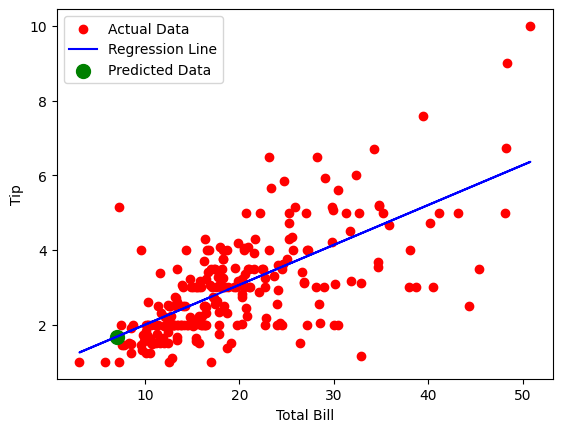

In [ ]:
plt.scatter(X, y, color="red", label="Actual Data")
plt.plot(X, lr.predict(X), color="blue", label="Regression Line")

plt.scatter([[7]], lr.predict([[7]]),
            color="green", label="Predicted Data", s=100)

plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.legend()
plt.show()


TASK 5

Saving IMG20220810200418.jpg to IMG20220810200418.jpg


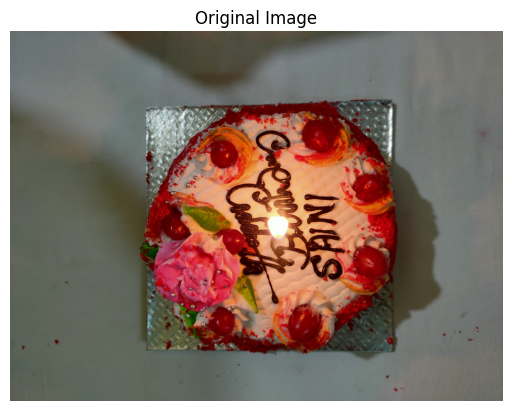

In [ ]:
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt
uploaded = files.upload()
img = Image.open(list(uploaded.keys())[0])
plt.imshow(img)
plt.axis('off')
plt.title("Original Image")
plt.show()


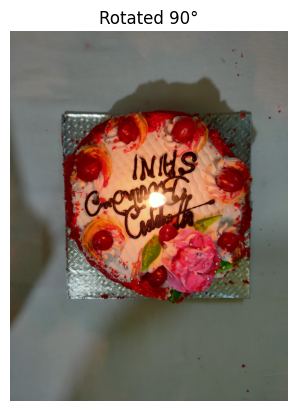

In [ ]:
angle = 90

rotated_img = img.rotate(angle, expand=True)

plt.imshow(rotated_img)
plt.axis('off')
plt.title(f"Rotated {angle}°")
plt.show()



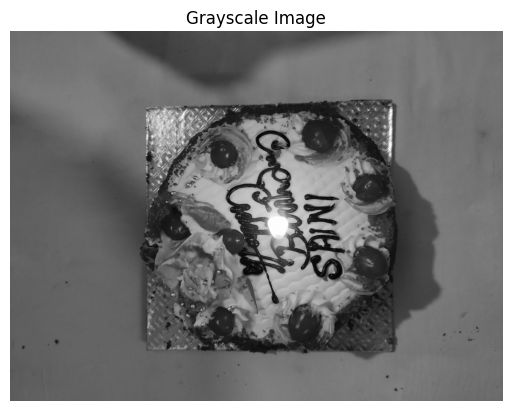

In [ ]:
gray_img = img.convert("L")

plt.imshow(gray_img, cmap='gray')
plt.axis('off')
plt.title("Grayscale Image")
plt.show()


Saving IMG-20240113-WA0006.jpg to IMG-20240113-WA0006.jpg


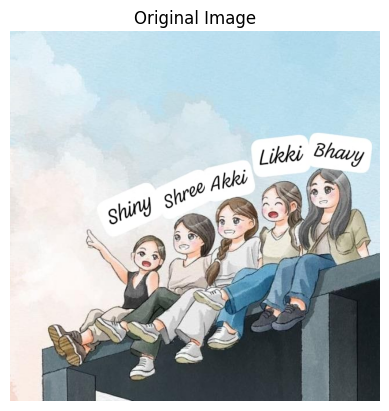

In [ ]:
from google.colab import files
import cv2
import matplotlib.pyplot as plt

uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# Read image (BGR)
img = cv2.imread(img_path)

# Convert to RGB for display
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis('off')
plt.title("Original Image")
plt.show()


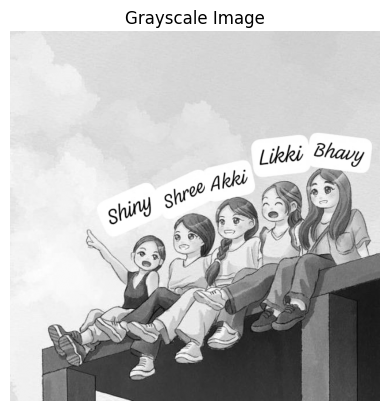

In [ ]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap='gray')
plt.axis('off')
plt.title("Grayscale Image")
plt.show()


In [ ]:
# Load cascades
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
body_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_fullbody.xml")

# Detect
faces = face_cascade.detectMultiScale(gray, 1.1, 4)
bodies = body_cascade.detectMultiScale(gray, 1.1, 4)

# Draw rectangles on RGB image
img_detect = img_rgb.copy()

for (x, y, w, h) in faces:
    cv2.rectangle(img_detect, (x, y), (x+w, y+h), (255, 0, 0), 2)

for (x, y, w, h) in bodies:
    cv2.rectangle(img_detect, (x, y), (x+w, y+h), (0, 255, 0), 2)


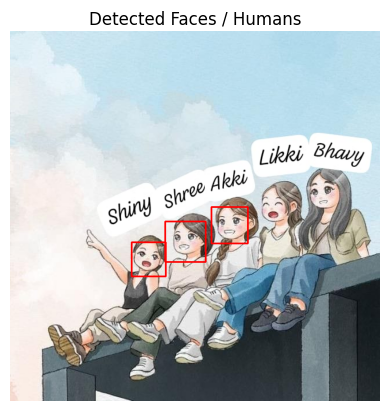

Number of faces: 3
Number of humans: 0


In [ ]:
plt.imshow(img_detect)
plt.axis('off')
plt.title("Detected Faces / Humans")
plt.show()

print("Number of faces:", len(faces))
print("Number of humans:", len(bodies))


Saving IMG-20240113-WA0006.jpg to IMG-20240113-WA0006.jpg
Image uploaded: IMG-20240113-WA0006.jpg


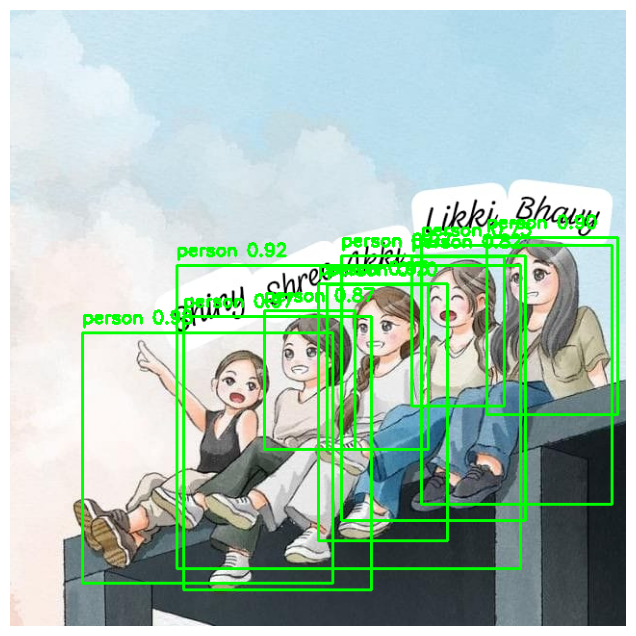

In [ ]:
import torch
import torchvision
from torchvision.transforms import functional as F
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_Weights
import cv2
import matplotlib.pyplot as plt
from google.colab import files

# ------------------------------
# Upload Image Dynamically
# ------------------------------
uploaded = files.upload()   # user uploads image
img_path = list(uploaded.keys())[0]   # get filename automatically

print("Image uploaded:", img_path)

# ------------------------------
# Load model
# ------------------------------
weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=weights)
model.eval()

# COCO labels
labels = weights.meta["categories"]

# ------------------------------
# Load & preprocess image
# ------------------------------
image = cv2.imread(img_path)
orig = image.copy()

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
tensor = F.to_tensor(image_rgb).unsqueeze(0)

# ------------------------------
# Run detection
# ------------------------------
with torch.no_grad():
    predictions = model(tensor)

boxes = predictions[0]["boxes"]
scores = predictions[0]["scores"]
classes = predictions[0]["labels"]

# ------------------------------
# Draw detections
# ------------------------------
for box, score, cls in zip(boxes, scores, classes):
    if score < 0.5:
        continue

    x1, y1, x2, y2 = box.int().tolist()
    label = f"{labels[cls]} {score:.2f}"

    cv2.rectangle(orig, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(orig, label, (x1, y1 - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

# ------------------------------
# Show result
# ------------------------------
plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()


In [ ]:
!pip install opencv-python matplotlib



In [ ]:
import torch
import torchvision
from torchvision.transforms import functional as F
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_Weights
import cv2
from google.colab.patches import cv2_imshow

weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=weights)
model.eval()
labels = weights.meta["categories"]

!wget -O human.jpg https://images.unsplash.com/photo-1529626455594-4ff0802cfb7e?ixlib=rb-4.0.3&auto=format&fit=crop&w=600&q=60

img_path = "/content/human.jpg"
image = cv2.imread(img_path)
orig = image.copy()
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
tensor = F.to_tensor(image_rgb).unsqueeze(0)

with torch.no_grad():
    predictions = model(tensor)

boxes = predictions[0]["boxes"]
scores = predictions[0]["scores"]
classes = predictions[0]["labels"]

for box, score, cls in zip(boxes, scores, classes):
    if score < 0.5:
        continue
    x1, y1, x2, y2 = box.int().tolist()
    label = f"{labels[cls.item()]}: {score:.2f}"
    cv2.rectangle(orig, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(orig, label, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

cv2_imshow(orig)


--2025-12-13 17:55:29--  https://images.unsplash.com/photo-1529626455594-4ff0802cfb7e?ixlib=rb-4.0.3
Resolving images.unsplash.com (images.unsplash.com)... 151.101.2.208, 151.101.66.208, 151.101.130.208, ...
Connecting to images.unsplash.com (images.unsplash.com)|151.101.2.208|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2010371 (1.9M) [image/jpeg]
Saving to: ‘human.jpg’

human.jpg           100%[===================>]   1.92M  --.-KB/s    in 0.08s   

2025-12-13 17:55:29 (25.0 MB/s) - ‘human.jpg’ saved [2010371/2010371]

